In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

In [8]:
from scipy import stats

In [9]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

sampling counts (using old schpf code)

## counts from fixed rate poisson

In [47]:
def counts_fixed_rate_pois(num_cell,num_gene,rate,seed=0):
    rng = np.random.default_rng(seed)
    return np.random.poisson(rate,size=(num_cell,num_gene)) 

In [48]:
# N < P
counts_fixed_rate_pois(10,100,0.1)
# N = P
counts_fixed_rate_pois(100,100,0.1)

counts_fixed_rate_pois(1000,100,0.1)

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# delete_dataset('counts_fixed_rate_pois',DATA_ROOT)

In [ ]:
dataset_type = 'counts_fixed_rate_pois'

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
rate_params_lst = [0.01,0.1,0.5,2,5,10]
random_seeds_lst = [321,435]

for rate_param in rate_params_lst:
    for n_samples, n_features in product(n_samples_lst, n_features_lst):
        
        # print(n_samples, n_features, X.shape)

        for sample_num,seed in enumerate(random_seeds_lst):
            
            X = counts_fixed_rate_pois(n_samples, n_features,rate=rate_param, seed=seed)
            params_dict = {
                'rate' : rate_param,
            }
                            
            try:
                save_dataset(X, 
                            generator=dataset_type,
                            params=params_dict,
                            seed=seed,
                            category=['counts'],
                            root=DATA_ROOT)

            except:
                print('file already exists')
        

## counts from gamma rate poisson

In [ ]:
def counts_gamma_rate_pois(num_cell,num_gene,gamma_shape=1,gamma_scale=1,lin_scale = 1,seed=0):
    rng = np.random.default_rng(seed)
    return np.fromfunction(lambda i,j : lin_scale*rng.poisson(rng.gamma(shape = gamma_shape,scale = gamma_scale + 0*i + 0*j)),shape=(num_cell,num_gene),dtype=int)

In [ ]:
# N < P
counts_gamma_rate_pois(10,100)
# N = P
counts_gamma_rate_pois(100,100)
# N > P
counts_gamma_rate_pois(1000,100)

array([[1, 2, 0, ..., 0, 1, 0],
       [0, 2, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 3, ..., 1, 0, 1],
       [0, 0, 1, ..., 0, 0, 4],
       [1, 0, 0, ..., 0, 0, 0]])

In [ ]:
dataset_type = 'counts_gamma_pois'

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
rate_params_lst = [0.01,0.1,0.5,2,5,10]
random_seeds_lst = [321,435]

gamma_shape_lst = [0.1, 0.5, 1, 5, 20, 100] #overdispersion
gamma_means_lst = [0.1, 1, 10, 100]

for gamma_shape in gamma_shape_lst:

    for gamma_mean in gamma_means_lst:
        
        gamma_scale = gamma_mean/gamma_shape
        
        for n_samples, n_features in product(n_samples_lst, n_features_lst):
            
            print(n_samples, n_features)

            for sample_num,seed in enumerate(random_seeds_lst):
                
                X = counts_gamma_rate_pois(n_samples, n_features,gamma_shape=gamma_shape,gamma_scale=gamma_scale, seed=seed)
                params_dict = {
                    'gamma_shape' : rate_param,
                    'gamma_scale' : rate_param,
                }
                                
                try:
                    save_dataset(X, 
                                generator=dataset_type,
                                params=params_dict,
                                seed=seed,
                                category=['counts'],
                                root=DATA_ROOT)

                except:
                    print('file already exists')
            

## counts from scHPF hierarchical model

In [ ]:
# this one is rewritten to be more efficient compared to the old code
def counts_schpf(num_cell, num_gene, num_factor=2, budget_shape=1,budget_rate=0.3, factor_shape=1, seed=None):
    rng = np.random.default_rng(seed)
    budget_cell = rng.gamma(budget_shape, 1 / budget_rate, num_cell)
    budget_gene = rng.gamma(budget_shape, 1 / budget_rate, num_gene)

    factor_cell = rng.gamma(factor_shape, 1 / budget_cell[:, None], (num_cell, num_factor))
    factor_gene = rng.gamma(factor_shape, 1 / budget_gene[:, None], (num_gene, num_factor))

    counts = rng.poisson(factor_cell @ factor_gene.T)
    return counts, [budget_cell, budget_gene, factor_cell, factor_gene]

## exponent of gamma rate poisson

not doing this because of floating pt errors for big numbers

In [ ]:
def counts_exponent_gamma_pois(num_cell,num_gene,gamma_shape=1,gamma_scale=1,expo_base = 2,seed=0):
    rng = np.random.default_rng(seed)
    
    pois_molecular_counts = np.fromfunction(lambda i,j : expo_base**rng.poisson(rng.gamma(shape = gamma_shape,scale = gamma_scale + 0*i + 0*j)),shape=(num_cell,num_gene),dtype=int)
    pois_molecular_counts[pois_molecular_counts==1]=0
    return pois_molecular_counts


In [ ]:
# N < P
counts_exponent_gamma_pois(10,100)
# N = P
counts_exponent_gamma_pois(100,100)
# N > P
counts_gamma_rate_pois(1000,100)

array([[ 0,  0,  2, ...,  4,  0,  4],
       [ 2,  0,  2, ...,  8,  2,  0],
       [ 8,  2,  2, ...,  0,  0,  0],
       ...,
       [ 0, 32,  4, ...,  2,  2,  0],
       [ 0,  0,  0, ..., 16,  2,  0],
       [16,  2,  2, ...,  8,  0, 16]])

## starting code for a block model of counts

In [ ]:
## block model of counts - FOR FUTURE, FUNC NEEDS TO BE MODIFIED
def counts_augmented_gamma_rate_pois(num_cell,num_gene,gamma_params_list,num_augment):
    pois_molecular_count_all = []
    
    for num_count in range(num_augment):
        pois_molecular_count_temp = counts_gamma_rate_pois(num_cell,num_gene,gamma_param=gamma_params_list[num_count])

        to_concat_array = [np.zeros(shape=(num_cell,num_gene),dtype=int) for i in range(num_augment)]
        to_concat_array[num_count] = pois_molecular_count_temp

        print(to_concat_array[num_count].shape)
        pois_molecular_count_all.append(np.concatenate(to_concat_array,axis=1))
    
    return np.concatenate(pois_molecular_count_all,dtype=int,axis=0)


In [ ]:
# OLD CODE FOR SCHPF from 2022
# inv_shape = 1
# inv_rate = 0.3
# inv_budget_cell = np.random.gamma(inv_shape,1/inv_rate,size=(num_cell))
# inv_budget_gene = np.random.gamma(inv_shape,1/inv_rate,size=(num_gene))

# num_factor = 2

# factor_cell = np.zeros(shape=(num_cell,num_factor))
# factor_gene = np.zeros(shape=(num_gene,num_factor))

# factor_shape = 1
# for ix in range(num_cell):
#     factor_cell[ix,:] = np.random.gamma(factor_shape,1/inv_budget_cell[ix],num_factor)
#     factor_gene[ix,:] = np.random.gamma(factor_shape,1/inv_budget_gene[ix],num_factor)

# pois_molecular_counts = np.zeros(shape=(num_cell,num_gene),dtype=int)
# for i_cell in range(num_cell):
#     for j_gene in range(num_gene):
#         pois_molecular_counts[i_cell,j_gene] = int(np.random.poisson(np.dot(factor_cell[i_cell,:],factor_gene[j_gene,:])))


## OTHER IDEAS / FOR FUTURE

## sample from a negative binomial, iid NxP, same params across features

parametrize negbinom as:

$x \sim NegBinom(r,p)$

$p = \frac{r}{r+mu}$

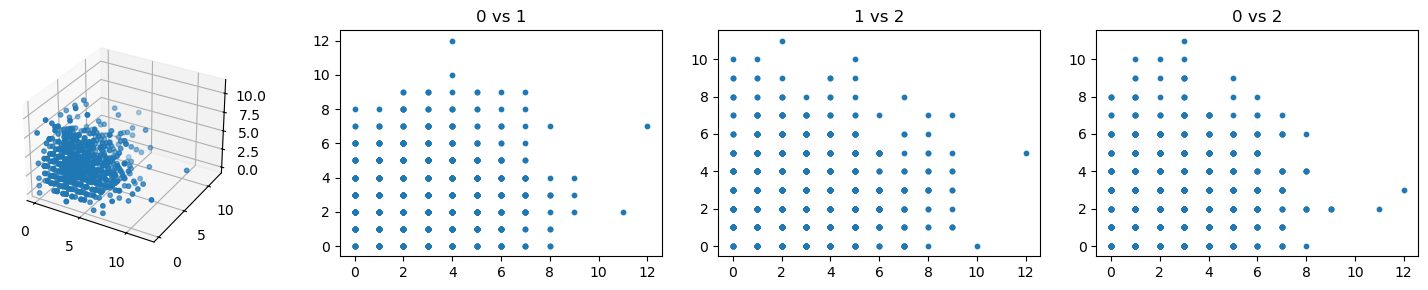

In [10]:
r = 10 #number of successes at which we stop
mu = 3 #mean of distr.
p = r / (r + mu)

seed = 0
n_samples = 1000
n_features = 100

rng = np.random.default_rng(seed)
X = rng.negative_binomial(r, r / (r + mu), size=(n_samples, n_features))
plot_3d_scatters(X,'')

## sample from negbinom, gamma prior on mu, r varying per feature

parametrize negbinom as:

$\mu_{feat} \sim gamma(shape_{\mu},scale_{\mu})$ --> per feature

$r_{feat} \sim gamma(shape_{r},scale_{r})$ --> per feature

$x \sim NegBinom(r,p), p = \frac{r}{r+\mu}$

---

for future:
can additionally scale $\mu$ per sample using a log-normal

$\mu_{sample} \sim lognormal(mean,scale)$

$\mu_{final} = \mu_{sample} * \mu_{feat}$

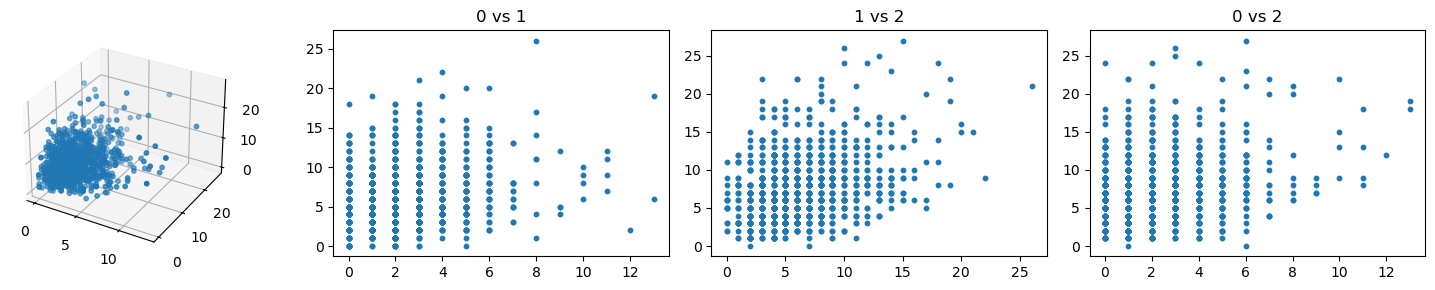

In [13]:
mu_per_feat = rng.gamma(shape=0.6, scale=1 / 0.3, size=n_features)
mu_scale_per_sample = rng.lognormal(0, 0.3, size=(n_samples, 1))
mu = mu_scale_per_sample * mu_per_feat

r = rng.gamma(shape=5.0, scale=2.0, size=n_features)

X = rng.negative_binomial(r, r / (r + mu))
plot_3d_scatters(X,'')

## sample from negbinom, using lognormal priors (ref DESEQ2)

$x_{ij} \sim NegBinom(\mu_{ij},\alpha_{i})$

assume the dispersion parameter α i follows a log-normal prior distribution that is centered around a trend that depends on the gene’s mean normalized read count

In [14]:
# r = 10
# mu_per_feat = rng.lognormal(np.log(mu), 1.0, size=n_features)
# mu_scale_per_sample = rng.lognormal(0, 0.3, size=(n_samples, 1))
# X = rng.poisson(r / (r + mu_scale_per_sample * mu_per_feat))
# plot_3d_scatters(X,'')